# Analisando dados com Python - I

## Dengue Brasil

### Pergunta Norteadora

In [4]:
print("Hello World!")

Hello World!


In [5]:
# Libs - Bibliotecas importantes

#Manipulação de Dados

import pandas as pd
import numpy as np

#Visaulizaçao de Dados
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

#obs: Aqui no VSCode, para ler excel é necessario instalar o pacote "openpyxl"

In [6]:
df_dengue = pd.read_excel("Base de Dados Dengue.xlsx")

In [7]:
df_dengue.head()

,municipio,uf,data_infeccoes,qtd_infeccoes
0,ALTA FLORESTA D'OESTE,RO,2013-01-01,34
1,ALTA FLORESTA D'OESTE,RO,2013-02-01,44
2,ALTA FLORESTA D'OESTE,RO,2013-03-01,15
3,ALTA FLORESTA D'OESTE,RO,2013-04-01,4
4,ALTA FLORESTA D'OESTE,RO,2013-05-01,3


In [8]:
df_dengue.head(20)

,municipio,uf,data_infeccoes,qtd_infeccoes
0,ALTA FLORESTA D'OESTE,RO,2013-01-01,34
1,ALTA FLORESTA D'OESTE,RO,2013-02-01,44
2,ALTA FLORESTA D'OESTE,RO,2013-03-01,15
3,ALTA FLORESTA D'OESTE,RO,2013-04-01,4
4,ALTA FLORESTA D'OESTE,RO,2013-05-01,3
5,ALTA FLORESTA D'OESTE,RO,2013-06-01,0
6,ALTA FLORESTA D'OESTE,RO,2013-07-01,0
7,ALTA FLORESTA D'OESTE,RO,2013-08-01,3
8,ALTA FLORESTA D'OESTE,RO,2013-09-01,0
9,ALTA FLORESTA D'OESTE,RO,2013-10-01,0


In [9]:
df_dengue.tail()

,municipio,uf,data_infeccoes,qtd_infeccoes
728767,BRASILIA,DF,2023-08-01,939
728768,BRASILIA,DF,2023-09-01,843
728769,BRASILIA,DF,2023-10-01,686
728770,BRASILIA,DF,2023-11-01,1300
728771,BRASILIA,DF,2023-12-01,5603


In [10]:
df_dengue.tail(20)

,municipio,uf,data_infeccoes,qtd_infeccoes
728752,BRASILIA,DF,2022-05-01,7395
728753,BRASILIA,DF,2022-06-01,4139
728754,BRASILIA,DF,2022-07-01,1818
728755,BRASILIA,DF,2022-08-01,1276
728756,BRASILIA,DF,2022-09-01,1385
728757,BRASILIA,DF,2022-10-01,1404
728758,BRASILIA,DF,2022-11-01,1194
728759,BRASILIA,DF,2022-12-01,2039
728760,BRASILIA,DF,2023-01-01,2084
728761,BRASILIA,DF,2023-02-01,2293


# Analisando dados com Python - II

# Explorando o Dataset

In [11]:
print(f'O tamanho do nosso DataSet: {df_dengue.shape}')
# f de Format

#Retorna -> (Quantidade de Registros, Quantidade de Colunas)

O tamanho do nosso DataSet: (728772, 4)


### Caracteristicas do DataSet

In [12]:
# Características do DataSet

type(df_dengue)

# tipo do nosso DataSet

pandas.DataFrame

In [13]:
# Características das colunas do DataSet

df_dengue.dtypes

#tipos das colunas do DataSet

municipio                    str
uf                           str
data_infeccoes    datetime64[us]
qtd_infeccoes              int64
dtype: object

Existe Valores Nulos?

In [14]:
df_dengue.isnull()

,municipio,uf,data_infeccoes,qtd_infeccoes
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
728767,False,False,False,False
728768,False,False,False,False
728769,False,False,False,False
728770,False,False,False,False


In [15]:
## Soma a qtd de valores nulos de cada coluna

df_dengue.isnull().sum()

municipio         0
uf                0
data_infeccoes    0
qtd_infeccoes     0
dtype: int64

In [16]:
## Verifica na tabela toda se existem valores nulos (tabela inteira)

df_dengue.isnull().sum().sum()

np.int64(0)

In [17]:
## printar na tela de forma melhor

print(f'Quantidade de Dados Nulos: {df_dengue.isnull().sum().sum()}')

Quantidade de Dados Nulos: 0


### Informações sobre a Base

In [18]:
# Uma unica função pra trazer dados das colunas e se tem valores nulos de uma so vez

df_dengue.info()

<class 'pandas.DataFrame'>
RangeIndex: 728772 entries, 0 to 728771
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   municipio       728772 non-null  str           
 1   uf              728772 non-null  str           
 2   data_infeccoes  728772 non-null  datetime64[us]
 3   qtd_infeccoes   728772 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 22.2 MB


Verificar valores únicos

###### É sabido que todos os estados tem caos de Dengue, então tem que ter 27 registros únicos de estados, já que nem todas as cidades do Brasil tem casos de dengue

In [19]:
df_dengue.nunique()

municipio         5243
uf                  27
data_infeccoes     132
qtd_infeccoes     1157
dtype: int64

Precisamos calcular a quantidade de pessoas que pegaram dengue por município por ano

In [20]:
# Criar uma coluna de ano

df_dengue ['ano'] = df_dengue['data_infeccoes'].dt.year

In [21]:
df_dengue.head()

,municipio,uf,data_infeccoes,qtd_infeccoes,ano
0,ALTA FLORESTA D'OESTE,RO,2013-01-01,34,2013
1,ALTA FLORESTA D'OESTE,RO,2013-02-01,44,2013
2,ALTA FLORESTA D'OESTE,RO,2013-03-01,15,2013
3,ALTA FLORESTA D'OESTE,RO,2013-04-01,4,2013
4,ALTA FLORESTA D'OESTE,RO,2013-05-01,3,2013


In [22]:
# Agrupar por ano e município

infeccoes_municipio = df_dengue.groupby(['ano', 'municipio', 'uf'])['qtd_infeccoes'].sum().reset_index()

In [23]:
infeccoes_municipio.head()

,ano,municipio,uf,qtd_infeccoes
0,2013,ABADIA DE GOIAS,GO,52
1,2013,ABADIA DOS DOURADOS,MG,0
2,2013,ABADIANIA,GO,37
3,2013,ABAETE,MG,486
4,2013,ABAETETUBA,PA,15


In [24]:
infeccoes_municipio.info()

<class 'pandas.DataFrame'>
RangeIndex: 60731 entries, 0 to 60730
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ano            60731 non-null  int32
 1   municipio      60731 non-null  str  
 2   uf             60731 non-null  str  
 3   qtd_infeccoes  60731 non-null  int64
dtypes: int32(1), int64(1), str(2)
memory usage: 1.6 MB


Agrupar por Estado e Ano

In [25]:
infeccoes_estado = df_dengue.groupby(['ano', 'uf'])['qtd_infeccoes'].sum().reset_index()

## O que o reset_index faze neste caso??

In [26]:
infeccoes_estado.head()

,ano,uf,qtd_infeccoes
0,2013,AC,1663
1,2013,AL,704
2,2013,AM,4327
3,2013,AP,546
4,2013,BA,13417


In [27]:
# Para trazer todos os dados, não coloco nenhuma função

infeccoes_estado

,ano,uf,qtd_infeccoes
0,2013,AC,1663
1,2013,AL,704
2,2013,AM,4327
3,2013,AP,546
4,2013,BA,13417
...,...,...,...
292,2023,RS,27389
293,2023,SC,77954
294,2023,SE,1749
295,2023,SP,198774


# Analisando dados com Python - III

## Estatística Descritiva

In [28]:
# Estatística básica do Python para colunas com dados numéricos
# mean -> média, no caso abaixo a média em 10 anos
# std -> Desvio Padrão, o quanto oscilou os casos -> ajuda a ponderar dizendo que a média pode oscilar pra cima ou pra baixo



infeccoes_estado.describe()

,ano,qtd_infeccoes
count,297.000000,297.000000
mean,2018.000000,12872.474747
std,3.167615,31630.107741
min,2013.000000,0.000000
25%,2015.000000,780.000000
50%,2018.000000,2229.000000
75%,2021.000000,10098.000000
max,2023.000000,286000.000000


## Conclusões da Análise acima

###### Dados analizados de todos os estados do Brasil + DF entre 2013 e 2023. Em média, nestes 10 anos, tivemos 12.872 casos.


### Interpretação da estatística descritiva utilizando o gráfico de BOXPLOT

<Axes: ylabel='qtd_infeccoes'>

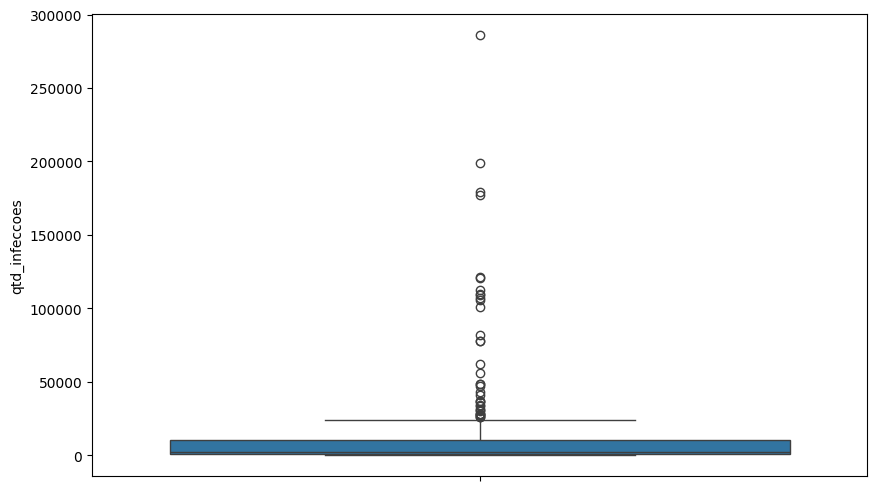

In [29]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = infeccoes_estado, y = 'qtd_infeccoes' )

<Axes: xlabel='ano', ylabel='qtd_infeccoes'>

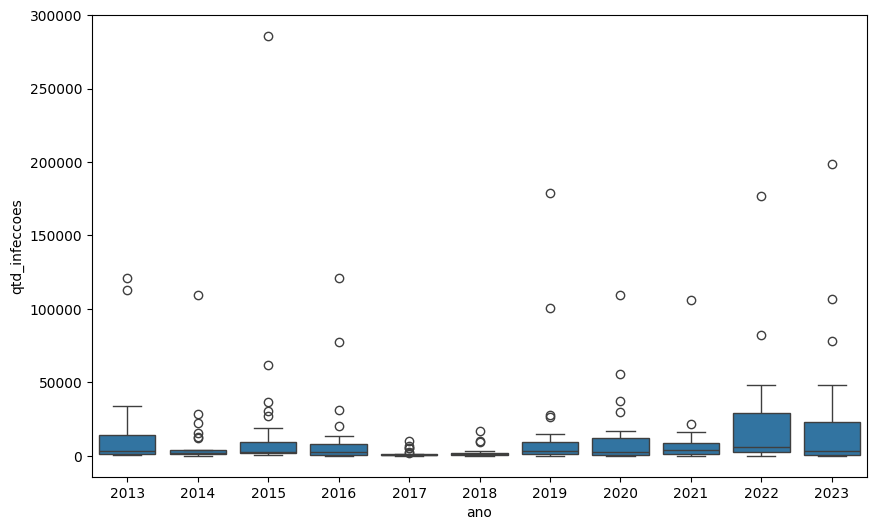

In [30]:
## uso das Libs Matplotlib.pyplot e Seaborn

## Seaborn usa o Matplotlib por trás, mas deixa os gráficos mais bonitos e melhor apresentáveis

# Criar boxplot comparando a qtd de infecções por ano

plt.figure(figsize = (10, 6))
sns.boxplot(data = infeccoes_estado, x = 'ano', y = 'qtd_infeccoes')

### Interpretando o gráfico

##### Mínimo representado pela linha no início de cada coluna, 75% representado pelo T, Bolinhas são os outliers. Azul é a grande massa de casos.

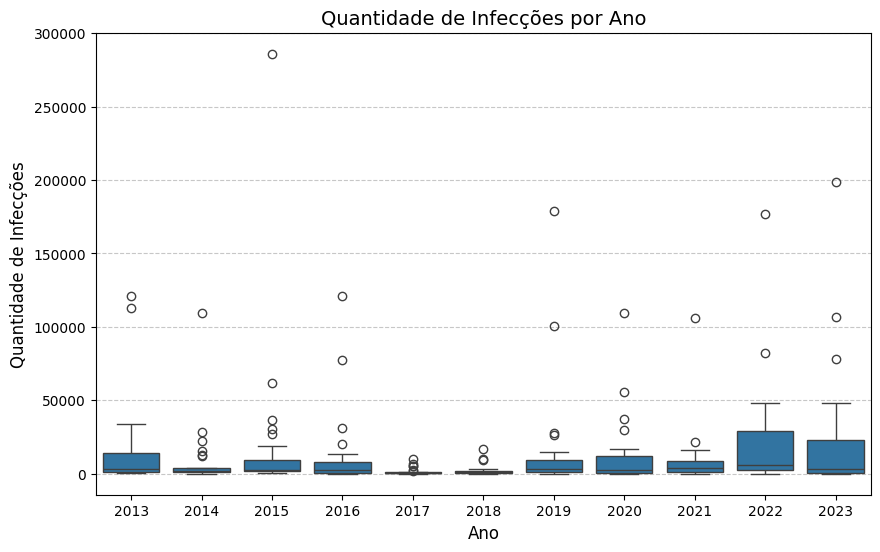

In [31]:
# Criar boxplot comparando a qtd de infecções por ano

plt.figure(figsize = (10, 6))
sns.boxplot(data = infeccoes_estado, x = 'ano', y = 'qtd_infeccoes')

# PERSONALIZAR O GRÁFICO

plt.title('Quantidade de Infecções por Ano', fontsize = 14)
plt.xlabel('Ano', fontsize = 12)
plt.ylabel('Quantidade de Infecções', fontsize = 12)
plt.grid(axis= 'y', linestyle = '--', alpha = 0.7)

plt.show()


/var/folders/vt/k0b4y37s7s90dbpr7rqn6vlm0000gn/T/ipykernel_58107/596535097.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = infeccoes_estado, x = 'ano', y = 'qtd_infeccoes', palette= 'viridis')


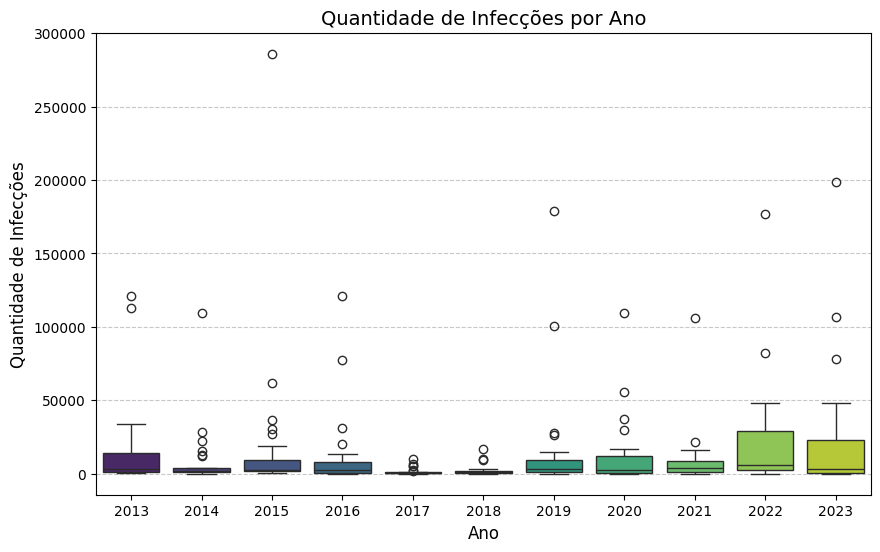

In [32]:
# Criar boxplot comparando a qtd de infecções por ano

plt.figure(figsize = (10, 6))
sns.boxplot(data = infeccoes_estado, x = 'ano', y = 'qtd_infeccoes', palette= 'viridis')

# PERSONALIZAR O GRÁFICO

plt.title('Quantidade de Infecções por Ano', fontsize = 14)
plt.xlabel('Ano', fontsize = 12)
plt.ylabel('Quantidade de Infecções', fontsize = 12)
plt.grid(axis= 'y', linestyle = '--', alpha = 0.7)

plt.show()


### Vamos olhar o ano de 2023

In [33]:
#filtrar os dados para o ano de 2023

infeccoes_estado_2023 = infeccoes_estado[infeccoes_estado['ano'] == 2023]

In [34]:
infeccoes_estado_2023

,ano,uf,qtd_infeccoes
270,2023,AC,1781
271,2023,AL,473
272,2023,AM,3263
273,2023,AP,742
274,2023,BA,13249
275,2023,CE,7437
276,2023,DF,23710
277,2023,ES,0
278,2023,GO,21682
279,2023,MA,2428


#### Entendendo o ano de 2023

In [35]:
infeccoes_estado_2023.describe()

,ano,qtd_infeccoes
count,27.0,27.000000
mean,2023.0,22902.888889
std,0.0,43368.215001
min,2023.0,0.000000
25%,2023.0,744.000000
50%,2023.0,3263.000000
75%,2023.0,22696.000000
max,2023.0,198774.000000


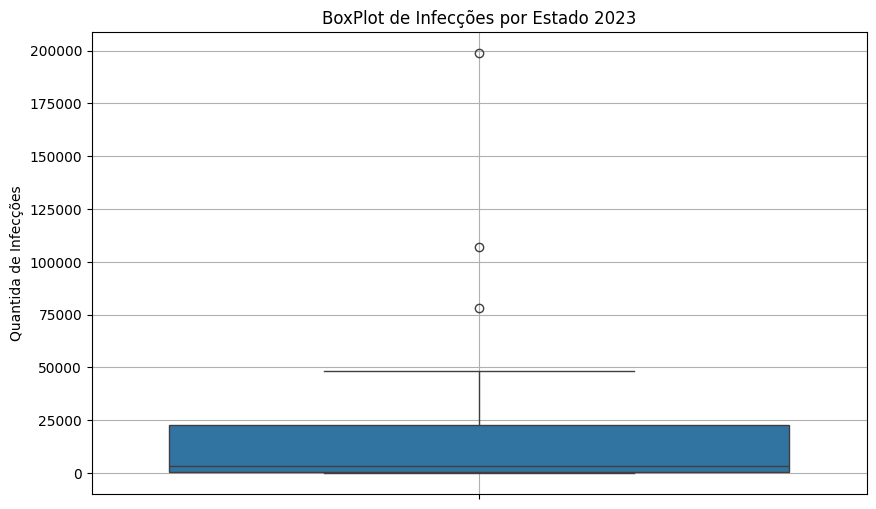

In [36]:
plt.figure(figsize = (10,6))
sns.boxplot(data = infeccoes_estado_2023, y = 'qtd_infeccoes')
plt.title('BoxPlot de Infecções por Estado 2023')
plt.ylabel('Quantida de Infecções')
plt.grid()


In [ ]:
#lib de visualização do plotly para gráfico interativo

## Aqui, tive que atualizar a lib nbformat -> pip install --upgrade nbformat

fig = px.box(infeccoes_estado_2023, y = 'qtd_infeccoes', title = 'Boxplot de Infecções por estado / 2023')
fig.show()

In [43]:
# mais detalhes

fig = px.box(infeccoes_estado_2023, x = 'uf', y = 'qtd_infeccoes', color = 'uf', title = 'Boxplot de Infecções por estado / 2023')
fig.show()

# Analisando dados com Python - IV

### Comparação: Utilizar gráfico de Barras ao invés do BoxPlot

#### Comparação entre os estados no ano de 2023

/var/folders/vt/k0b4y37s7s90dbpr7rqn6vlm0000gn/T/ipykernel_58107/2736141415.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = infeccoes_estado_2023, x = 'uf', y = 'qtd_infeccoes', palette = 'viridis')


<Axes: xlabel='uf', ylabel='qtd_infeccoes'>

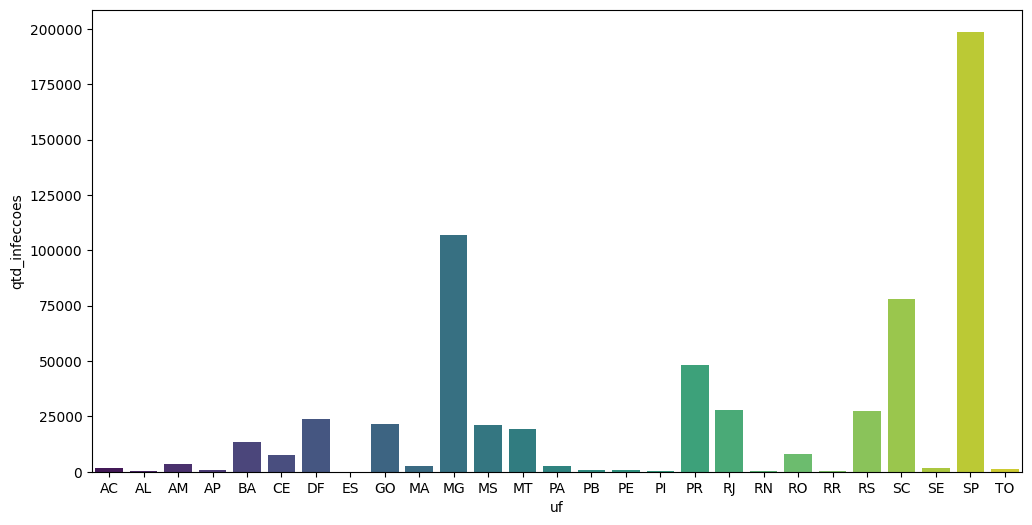

In [ ]:
# Criar gráfico de barras comparando a quantidade de infecções por estado em 2023, utilizando Seaborn
plt.figure(figsize = (12,6))
sns.barplot(data = infeccoes_estado_2023, x = 'uf', y = 'qtd_infeccoes', palette = 'viridis')

/var/folders/vt/k0b4y37s7s90dbpr7rqn6vlm0000gn/T/ipykernel_58107/2068558348.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = infeccoes_estado_2023, x = 'uf', y = 'qtd_infeccoes', palette = 'viridis')


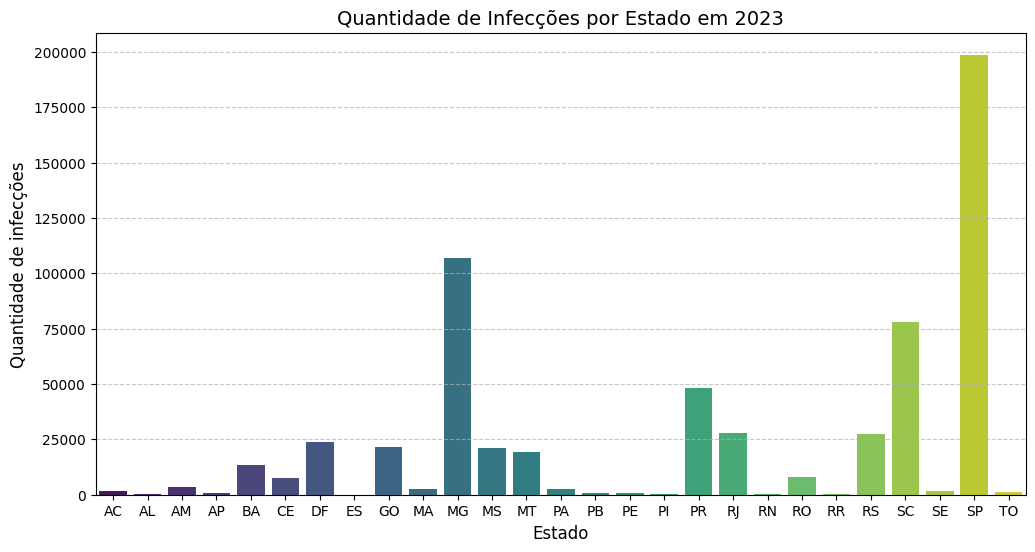

In [46]:
plt.figure(figsize = (12,6))
sns.barplot(data = infeccoes_estado_2023, x = 'uf', y = 'qtd_infeccoes', palette = 'viridis')

#Personalizar o gráfico

plt.title('Quantidade de Infecções por Estado em 2023', fontsize = 14)
plt.xlabel('Estado', fontsize = 12)
plt.ylabel('Quantidade de infecções', fontsize = 12)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)

#exibir o gráfico

plt.show()

In [50]:
# Classificar por quantidade, do maior para o menor

infeccoes_2023_ranking = infeccoes_estado_2023.sort_values(by = 'qtd_infeccoes', ascending = False)

In [51]:
infeccoes_2023_ranking

,ano,uf,qtd_infeccoes
295,2023,SP,198774
280,2023,MG,106923
293,2023,SC,77954
287,2023,PR,48328
288,2023,RJ,27905
292,2023,RS,27389
276,2023,DF,23710
278,2023,GO,21682
281,2023,MS,21098
282,2023,MT,19356


/var/folders/vt/k0b4y37s7s90dbpr7rqn6vlm0000gn/T/ipykernel_58107/3175086032.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=infeccoes_2023_ranking, x = 'uf', y = 'qtd_infeccoes', palette = 'viridis')


<Axes: xlabel='uf', ylabel='qtd_infeccoes'>

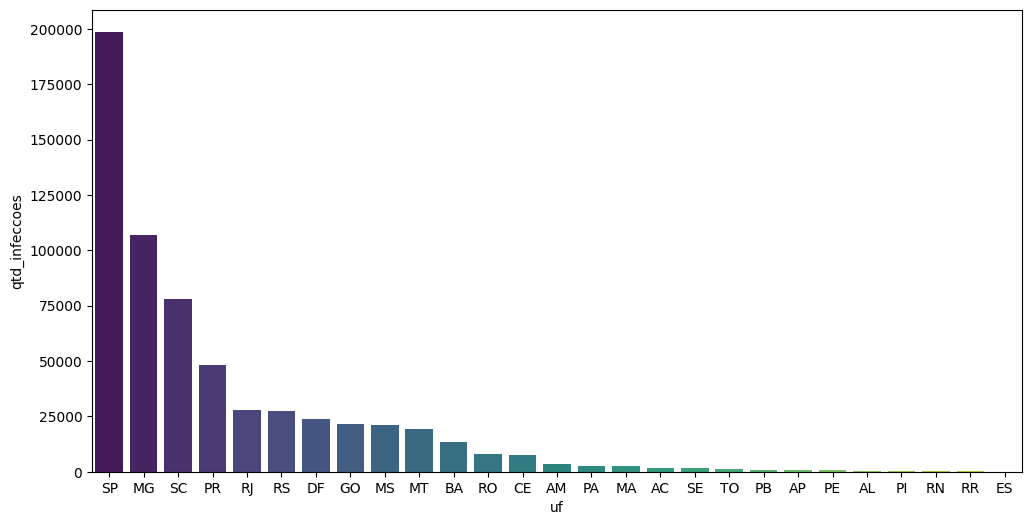

In [54]:
# criar um novo gráfico de barras comparando os estados de forma ordenada

plt.figure(figsize = (12,6))
sns.barplot(data=infeccoes_2023_ranking, x = 'uf', y = 'qtd_infeccoes', palette = 'viridis')

/var/folders/vt/k0b4y37s7s90dbpr7rqn6vlm0000gn/T/ipykernel_58107/1411727043.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = infeccoes_2023_ranking, x = 'uf', y = 'qtd_infeccoes', palette = 'viridis')


(array([     0.,  25000.,  50000.,  75000., 100000., 125000., 150000.,
        175000., 200000., 225000.]),
 [Text(0, 0.0, '0'),
  Text(0, 25000.0, '25000'),
  Text(0, 50000.0, '50000'),
  Text(0, 75000.0, '75000'),
  Text(0, 100000.0, '100000'),
  Text(0, 125000.0, '125000'),
  Text(0, 150000.0, '150000'),
  Text(0, 175000.0, '175000'),
  Text(0, 200000.0, '200000'),
  Text(0, 225000.0, '225000')])

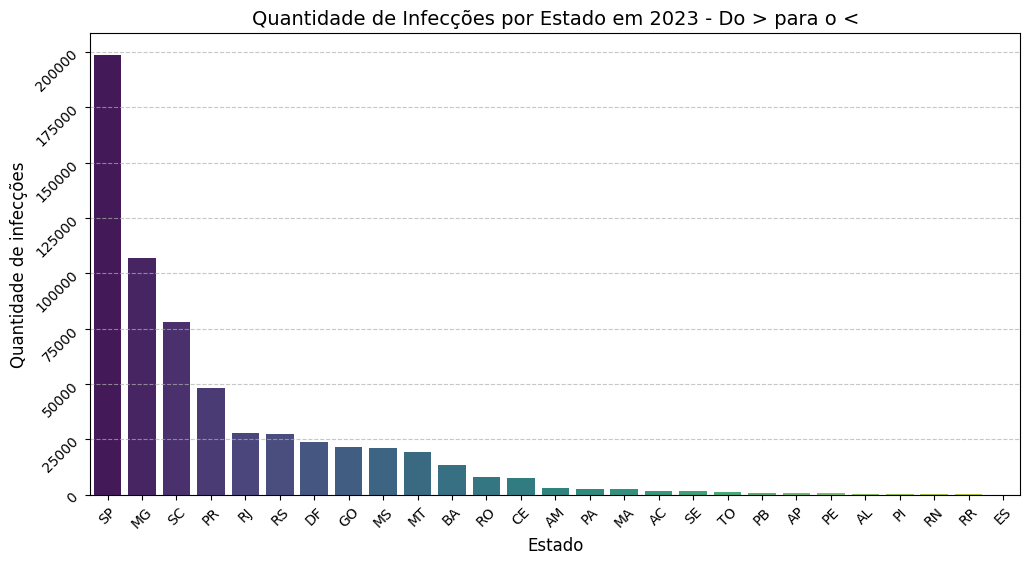

In [57]:
plt.figure(figsize = (12,6))
sns.barplot(data = infeccoes_2023_ranking, x = 'uf', y = 'qtd_infeccoes', palette = 'viridis')

## personalizando o gráfico

plt.title('Quantidade de Infecções por Estado em 2023 - Do > para o <', fontsize = 14)
plt.xlabel('Estado', fontsize = 12)
plt.ylabel('Quantidade de infecções', fontsize = 12)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
#rotacionar o eixo, neste caso o X
plt.xticks(rotation = 45)
#rotacionar o eixo, neste caso o X
plt.yticks(rotation = 45)

#exibir o gráfico

#plt.show()

/var/folders/vt/k0b4y37s7s90dbpr7rqn6vlm0000gn/T/ipykernel_58107/476178808.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = infeccoes_2023_ranking, x = 'uf', y = 'qtd_infeccoes', palette = 'viridis')


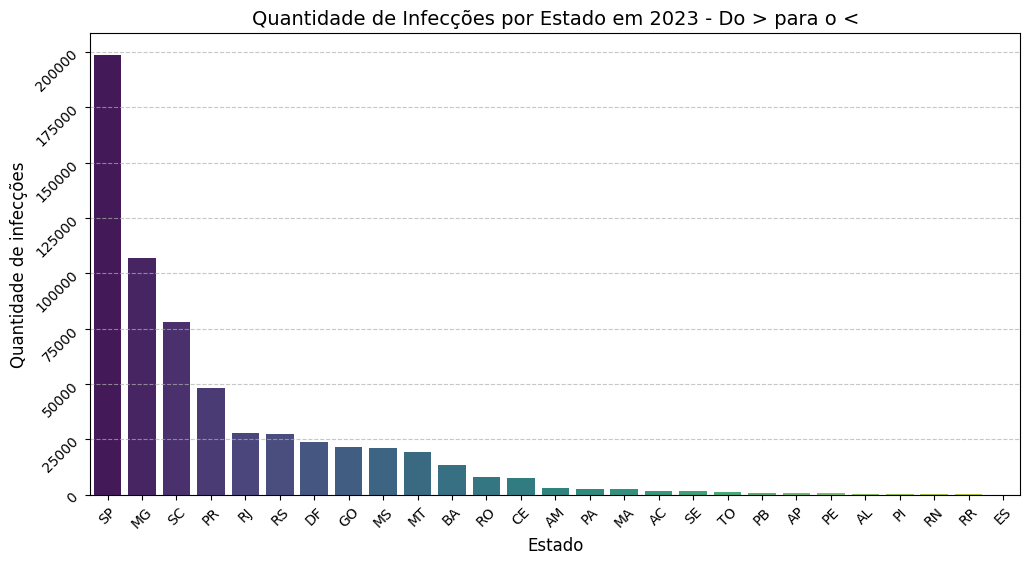

In [58]:
plt.figure(figsize = (12,6))
sns.barplot(data = infeccoes_2023_ranking, x = 'uf', y = 'qtd_infeccoes', palette = 'viridis')

## personalizando o gráfico

plt.title('Quantidade de Infecções por Estado em 2023 - Do > para o <', fontsize = 14)
plt.xlabel('Estado', fontsize = 12)
plt.ylabel('Quantidade de infecções', fontsize = 12)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
#rotacionar o eixo, neste caso o X
plt.xticks(rotation = 45)
#rotacionar o eixo, neste caso o X
plt.yticks(rotation = 45)

#exibir o gráfico

plt.show()

#com o plt.show para retirar comentários inúteis

## Gráficos de Tendências

<Axes: xlabel='ano', ylabel='qtd_infeccoes'>

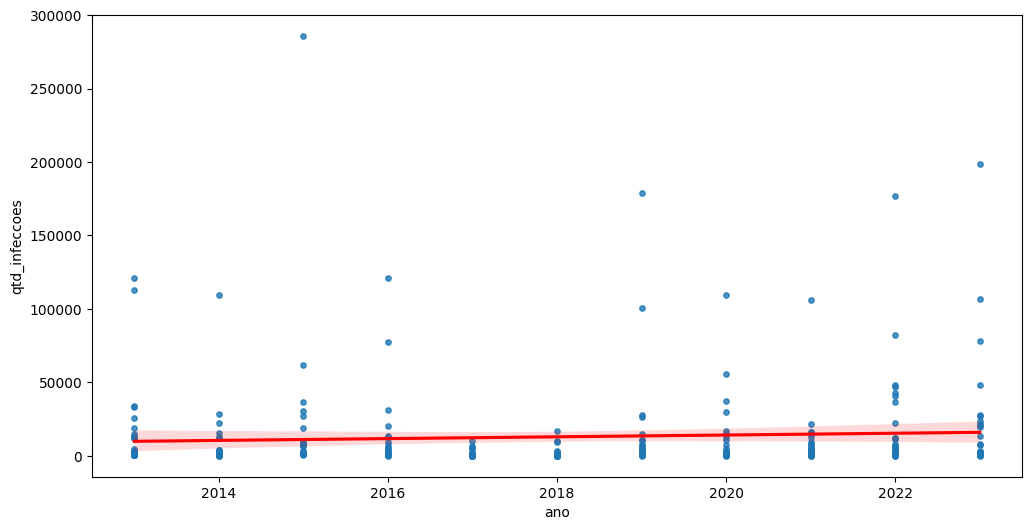

In [ ]:
#criar o gráfico de Tendência (geralmente gráfico com linhas) - neste caso vamos fazer gráfico de dispensão com gráfico de linhas

plt.figure(figsize= (12,6))
sns.regplot(data = infeccoes_estado, x = 'ano', y = 'qtd_infeccoes', scatter_kws = {"s":15}, line_kws = {"color":"red"})

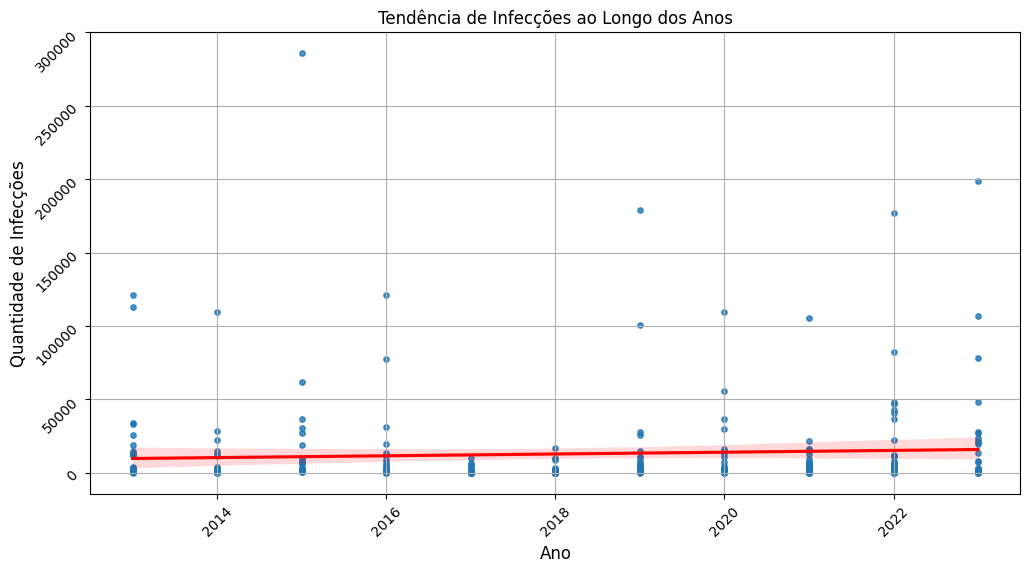

In [65]:
plt.figure(figsize= (12,6))
sns.regplot(data = infeccoes_estado, x = 'ano', y = 'qtd_infeccoes', scatter_kws = {"s":15}, line_kws = {"color":"red"})

#Personalizar o Gráfico

plt.title('Tendência de Infecções ao Longo dos Anos', fontsize = 12)
plt.xlabel('Ano', fontsize = 12)
plt.ylabel('Quantidade de Infecções', fontsize = 12)
plt.grid(True)
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)

plt.show()